In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

--- AUTOMATIC CALCULATION ---
Detected Dominant Grass Hue: 24
Calculated Lower Bound: [ 0, 20, 20 ]
Calculated Upper Bound: [ 54, 255, 255 ]



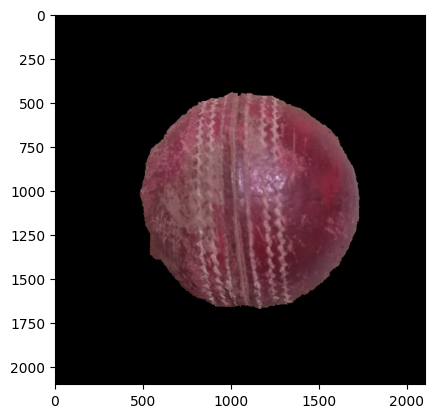

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image and convert to HSV
image_path = '../data/raw/seam.jpg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. Extract ONLY the Hue Channel (Index 0)
hue_channel = hsv[:, :, 0]

# 3. Calculate the Histogram for the Hue channel (0 to 180)
# cv2.calcHist(images, channels, mask, histSize, ranges)
hue_hist = cv2.calcHist([hue_channel], [0], None, [180], [0, 180])

# 4. Find the Peak (The most dominant color, which MUST be the grass)
# argmax() returns the index (the exact Hue number) with the highest pixel count
peak_hue = np.argmax(hue_hist)

# 5. DYNAMICALLY CALCULATE THE BOUNDS (Create a +/- 15 window around the peak)
hue_margin = 30
lower_hue = max(0, peak_hue - hue_margin)
upper_hue = min(179, peak_hue + hue_margin)

print(f"--- AUTOMATIC CALCULATION ---")
print(f"Detected Dominant Grass Hue: {peak_hue}")
print(f"Calculated Lower Bound: [ {lower_hue}, 20, 20 ]")
print(f"Calculated Upper Bound: [ {upper_hue}, 255, 255 ]\n")

# 6. Apply our dynamically calculated bounds to the standard inRange function
# (We keep Saturation and Value wide open to survive shadows and sun glare)
lower_green = np.array([lower_hue, 20, 20])
upper_green = np.array([upper_hue, 255, 255])

bg_mask = cv2.inRange(hsv, lower_green, upper_green)

# Invert to get the ball
ball_mask = cv2.bitwise_not(bg_mask)

# 7. Morphological Cleanup (Just like your original code)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
cleaned_mask = cv2.morphologyEx(ball_mask, cv2.MORPH_OPEN, kernel)
contours,_ =cv2.findContours(ball_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Get largest contour and prune it
    largest_contour = max(contours, key=cv2.contourArea)
    epsilon = 0.00002 * cv2.arcLength(largest_contour, True)
    pruned_contour = cv2.approxPolyDP(largest_contour, epsilon, True)

    final_segmented_mask_2 = np.zeros_like(cleaned_mask)
    cv2.drawContours(final_segmented_mask_2, [largest_contour], -1, 255, -1)

    isolated_ball_2 = cv2.bitwise_and(img_rgb, img_rgb, mask=final_segmented_mask_2)

plt.imshow(isolated_ball_2)
plt.show()

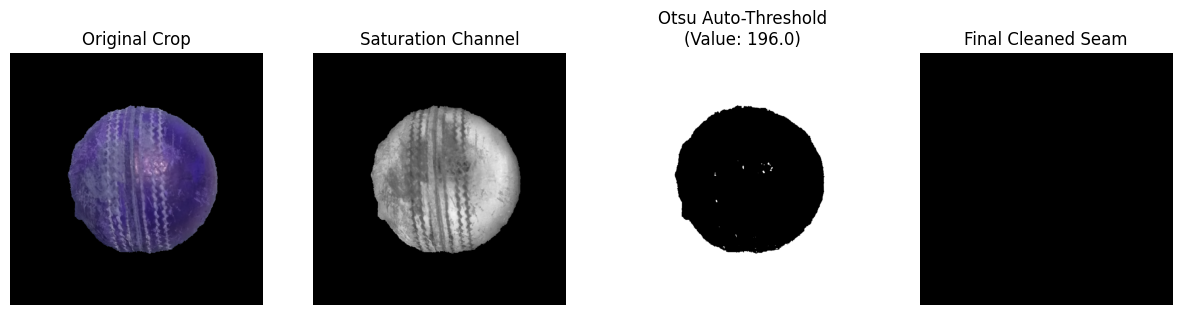

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Start with the tightly cropped ball from Phase 1

ball_crop = isolated_ball_2

# 2. Convert to HSV
hsv_ball = cv2.cvtColor(ball_crop, cv2.COLOR_BGR2HSV)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ASSUMPTIONS: 
# 1. 'hsv_ball' is your cropped HSV image.
# 2. 'ball_mask' is the perfect black & white mask of the ball from Phase 1.

# 1. Extract ONLY the Saturation Channel
saturation_channel = hsv_ball[:, :, 1]

# 2. THE FIX: Extract only the pixels that belong to the ball
# This creates a flat list of pixels, completely ignoring the black background (0s)
safe_ball_pixels = saturation_channel[ball_mask == 255]

# 3. OpenCV requires a 2D array for thresholding, so we quickly reshape our list
safe_ball_pixels_2d = safe_ball_pixels.reshape(-1, 1)

# 4. Calculate Otsu's threshold ONLY on the safe pixels
optimal_thresh, _ = cv2.threshold(
    safe_ball_pixels_2d, 
    0, 255, 
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Masked Otsu mathematically calculated the threshold at: {optimal_thresh}")

# 5. Apply that perfect threshold manually to the entire original Saturation channel.
# We use THRESH_BINARY_INV because the seam has LOW saturation. 
# This turns the low-saturation seam into bright WHITE (255).
_, raw_seam_mask = cv2.threshold(
    saturation_channel, 
    optimal_thresh, 
    255, 
    cv2.THRESH_BINARY_INV
)

# 6. THE FINAL CLEANUP
# Because we used THRESH_BINARY_INV, the black background (0 saturation) 
# also turned white! We simply use our Phase 1 mask to delete the background again.
final_seam_mask = cv2.bitwise_and(raw_seam_mask, raw_seam_mask, mask=ball_mask)

# --- VISUALIZATION ---
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.title("1. Saturation Channel")
plt.imshow(saturation_channel, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("2. Phase 1 Ball Mask")
plt.imshow(ball_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title(f"3. Raw Inv Threshold\n(Notice the background!)")
plt.imshow(raw_seam_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("4. Final Cleaned Seam")
plt.imshow(final_seam_mask, cmap='gray')
plt.axis('off')

plt.show()
plt.title("Final Cleaned Seam")
plt.imshow(final_seam_mask, cmap='gray')
plt.axis('off')

plt.show()